# Solution 2C: Data Quality Checks
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_parquet("merged.parquet")
print(f"Loaded: {len(df_raw):,} rows, {df_raw.shape[1]} columns")
print(f"Date range: {df_raw['month'].min()} to {df_raw['month'].max()}")

Loaded: 533,156 rows, 20 columns
Date range: 2011-02 to 2025-11


## 1. Variable coverage

In [2]:
print("Variable coverage (fraction non-missing):")
for col in df_raw.columns:
    frac = df_raw[col].notna().mean()
    print(f"  {col:20s}: {frac:.4f}")

Variable coverage (fraction non-missing):
  ticker              : 1.0000
  month               : 1.0000
  close               : 1.0000
  return              : 1.0000
  momentum            : 1.0000
  lag_month           : 1.0000
  industry            : 1.0000
  sector              : 1.0000
  marketcap           : 1.0000


  size                : 1.0000
  assets              : 1.0000
  assetturnover       : 1.0000
  leverage            : 1.0000
  equity              : 1.0000
  gp                  : 1.0000
  grossmargin         : 1.0000
  roe                 : 1.0000
  asset_growth        : 1.0000
  gp_to_assets        : 1.0000
  pb                  : 1.0000


## 2. Cross-sectional means over time

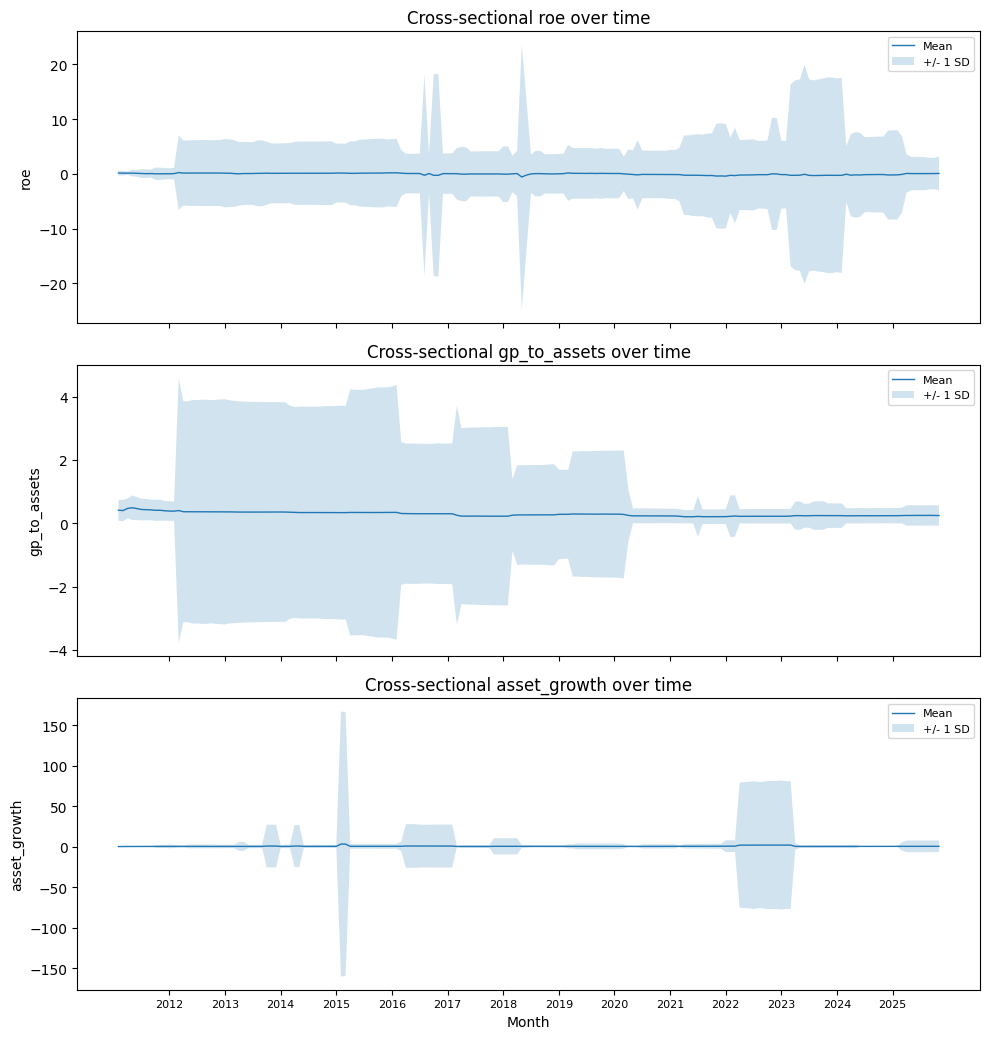

In [3]:
ts_vars = [v for v in ["roe", "gp_to_assets", "asset_growth"] if v in df_raw.columns]
df_ts = df_raw.dropna(subset=ts_vars)
monthly_stats = df_ts.groupby("month")[ts_vars].agg(["mean", "std"])

fig, axes = plt.subplots(len(ts_vars), 1, figsize=(10, 3.5 * len(ts_vars)), sharex=True)
if len(ts_vars) == 1:
    axes = [axes]
for i, var in enumerate(ts_vars):
    means = monthly_stats[(var, "mean")]
    stds = monthly_stats[(var, "std")]
    ax = axes[i]
    ax.plot(range(len(means)), means.values, label="Mean", linewidth=1)
    ax.fill_between(range(len(means)), means.values - stds.values,
                    means.values + stds.values, alpha=0.2, label="+/- 1 SD")
    ax.set_ylabel(var)
    ax.legend(fontsize=8)
    ax.set_title(f"Cross-sectional {var} over time")
    year_ticks = [j for j, m in enumerate(means.index) if m.endswith("-01")]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([means.index[j][:4] for j in year_ticks], fontsize=8)
axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.show()

The means are generally stable over time, though `asset_growth` shows more variation.

## 3. Extreme outliers

In [4]:
if "roe" in df_raw.columns:
    roe_ext = (df_raw["roe"].abs() > 1.0).mean()
    print(f"Fraction of |roe| > 1.0: {roe_ext:.4f} ({roe_ext:.2%})")
if "asset_growth" in df_raw.columns:
    ag_ext = (df_raw["asset_growth"].abs() > 5.0).mean()
    print(f"Fraction of |asset_growth| > 5.0: {ag_ext:.4f} ({ag_ext:.2%})")

Fraction of |roe| > 1.0: 0.0635 (6.35%)
Fraction of |asset_growth| > 5.0: 0.0053 (0.53%)


## 4. Final dataset

In [5]:
df_clean = df_raw[df_raw["close"] >= 5.0].copy()
df_clean = df_clean.dropna()
print(f"Final dataset shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

df_clean.to_parquet("merged.parquet", index=False)
print("Saved: merged.parquet")

Final dataset shape: (533156, 20)
Columns: ['ticker', 'month', 'close', 'return', 'momentum', 'lag_month', 'industry', 'sector', 'marketcap', 'size', 'assets', 'assetturnover', 'leverage', 'equity', 'gp', 'grossmargin', 'roe', 'asset_growth', 'gp_to_assets', 'pb']


Saved: merged.parquet
